#### Assignment 1: Random Projections

> *Course: Machine Learning 2*

> *Prof: Jan Nagler*

> *Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang*

## Structure of this Jupyter Notebook - ML2 Assignment 1
In order to complete the assignment we structure the task in seven steps. The first five (1-5) are done for each dataset. In step 6 we compare the results of both datasets to eachother and finally in step 7 we summarize our findings and conclude with our learnings and take-aways.

In this section we provide a brief description of each step

### 1. Loading the Dataset(s)  
Load and preprocess the datasets (e.g., normalization, splitting), which prepares the data but is independent of the Random Projection method itself. 

- Dataset 1: **COIL-20**
    - The COIL-20 (Columbia Object Image Library) dataset consists of grayscale images of 20 different objects, each captured from multiple angles (typically 72 views per object, taken at 5° intervals).  
    - Each image is usually represented as a 32×32 pixel grid, resulting in a 1024-dimensional feature space when flattened.
    - Why we chose this dataset:
        - COIL-20 is well-suited for Random Projection because it is inherently high-dimensional while the underlying structure lies on a much lower-dimensional manifold (due to smooth rotations of objects).  
        - This makes it an ideal candidate for dimensionality reduction methods like Random Projection, which aim to preserve pairwise distances while significantly reducing dimensionality, enabling faster computation with minimal loss in classification performance.

- Dataset 2: **Breast Cancer**
    - The Breast Cancer dataset consists of medical diagnostic data for classifying tumors as malignant or benign.It contains 569 samples, each described by 30 numerical features extracted from digitized images of cell nuclei.
    - Each sample is represented in a 30-dimensional feature space, capturing characteristics such as texture, radius, smoothness, and concavity.
    - Why we chose this dataset:
        - The Breast Cancer dataset provides a contrast to COIL-20, as it is lower-dimensional and structured as tabular data rather than images.
        - Unlike COIL-20, the data does not lie on a clear low-dimensional manifold, making it useful for testing Random Projection in less structured settings.
        - This allows us to analyze whether Random Projection can still preserve relevant information and maintain classification performance when the underlying structure is less geometric.

---

### 2. Johnson–Lindenstrauss Bound  
The Johnson–Lindenstrauss (JL) lemma guarantees that high-dimensional data can be projected into a lower-dimensional space while approximately preserving pairwise distances.  

The required target dimension $k$ is bounded by:  

$$
k \geq \frac{4 \ln(n)}{\frac{\varepsilon^2}{2} - \frac{\varepsilon^3}{3}}
$$

This ensures that distances are preserved within a factor of $(1 \pm \varepsilon)$ for $n$ samples.

---

### 3. Getting Baseline Accuracy  
Train and evaluate a model on the original high-dimensional data to obtain a baseline performance.  
This serves as a reference point to quantify how much performance is affected by dimensionality reduction.

---

### 4. Sparse Random Projection  
Project the data into a lower-dimensional space using a sparse random matrix, where most entries are zero and a few are randomly sampled (e.g., from \{-1, 0, +1\}).  
This reduces computational cost and memory usage while approximately preserving distances as guaranteed by the JL lemma.

---

### 5. Ensembled Random Projection  
We apply Sparse Random Projection together with a LinearSVC classifier for both datasets. To reduce the variability caused by randomness, we perform 25 independent random projections for each target dimensionality using different random seeds. The final performance is obtained by averaging the classification accuracy across all runs, resulting in smoother and more stable curves.

---

### 6. Comparison of the Datasets  
Evaluate and compare how both datasets behave under Random Projection in terms of accuracy, dimensionality reduction, and stability.  
This highlights how dataset characteristics (e.g., sparsity, intrinsic dimensionality) influence the effectiveness of the method.

---

### 7. Conclusion (Final Section in Notebook)  
Summarize the trade-offs between dimensionality reduction and performance, and discuss when Random Projection is effective based on the observed results.

In [2]:
# Importing necessary libraries
from sklearn.random_projection import SparseRandomProjection
from sklearn.random_projection import johnson_lindenstrauss_min_dim
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import warnings
import io, urllib,os
import zipfile
from PIL import Image
warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42)  

#### A. Columbia Object Image Library dataset (COIL-20)

Description:

- It contains 1440 grayscale images of 20 objects each photographed from 72 different rotation angles.
- `128x128` pixels giving `16,384` features per image.
- Images live in Euclidean space, where pixel to pixel distance is a valid similarity measure and is suitable for random projections.


**1. Loading the dataset**

In [41]:
# Downloading the COIL-20 dataset
response = urllib.request.urlopen('http://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-20/coil-20-proc.zip')
zip_bytes = io.BytesIO(response.read())
X_coil, y_coil = [], []
with zipfile.ZipFile(zip_bytes) as zf:
    for fname in sorted(zf.namelist()):
        if fname.endswith('.png'):
            label = int(fname.split('obj')[1].split('_')[0]) - 1
            img_bytes = io.BytesIO(zf.read(fname))
            img = Image.open(img_bytes).convert('L')
            X_coil.append(np.array(img).flatten().astype('float32') / 255.0)
            y_coil.append(label)
X_coil = np.array(X_coil)
y_coil = np.array(y_coil)
print('COIL-20 shape:', X_coil.shape)
print('Number of classes:', len(np.unique(y_coil)))

COIL-20 shape: (1440, 16384)
Number of classes: 20


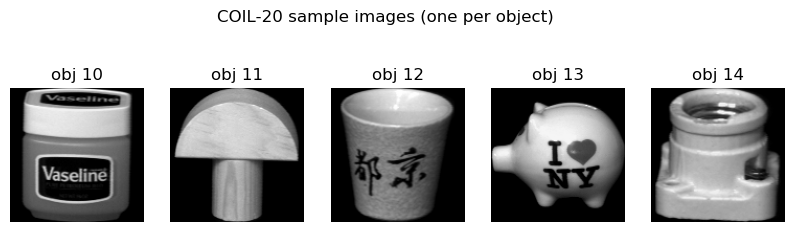

In [42]:
# Displaying some sample images from the dataset
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_coil[i * 72].reshape(128, 128), cmap='gray')
    ax.set_title('obj %d' % (y_coil[i * 72] + 1))
    ax.axis('off')
plt.suptitle('COIL-20 sample images (one per object)')
plt.show()

In [43]:
# Splitting the dataset into training and testing sets (70% train, 30% test)
X_coil_train, X_coil_test, y_coil_train, y_coil_test = train_test_split(X_coil, y_coil, test_size=0.3, random_state=42)
print('Train size:', X_coil_train.shape)
print('Test size: ', X_coil_test.shape)
print('Feature dimension (original):', X_coil_train.shape[1])

Train size: (1008, 16384)
Test size:  (432, 16384)
Feature dimension (original): 16384


**2. Johnson and Lindenstrauss Bound**

In [44]:
# Johnson-Lidenstrauss bound for COIL-20 (eps=0.1)
# For n=1440 samples, dimension d=128x128=16384 (pixels)
print('Professors Johnson and Lindenstrauss say: k >=',johnson_lindenstrauss_min_dim(len(X_coil), eps=0.1))

Professors Johnson and Lindenstrauss say: k >= 6233


**3. Getting baseline accuracy** 

In [45]:
model_coil=LinearSVC(random_state=42,max_iter=2000)
model_coil.fit(X_coil_train, y_coil_train)
baseline_coil=metrics.accuracy_score(y_coil_test, model_coil.predict(X_coil_test))
print('Baseline accuracy (no projection): %.4f' % baseline_coil)

Baseline accuracy (no projection): 0.9907


**4. Sparse Random Projection**

In [46]:
# Applying sparse random projection for varying dimensions
accuracies_coil = []
dims_coil = np.int32(np.linspace(2, 500, 20))
for dim in dims_coil:
    sp = SparseRandomProjection(n_components=dim, random_state=42)
    X_proj = sp.fit_transform(X_coil_train)
    model = LinearSVC(max_iter=2000)
    model.fit(X_proj, y_coil_train)
    test_proj = sp.transform(X_coil_test)
    accuracies_coil.append(metrics.accuracy_score(y_coil_test, model.predict(test_proj)))

**5. Ensembled Random Projection**

In [57]:
# Applying ensembled sparse random projection over multiple realizations
n_realizations = 25
accuracies_coil_ens = np.zeros((n_realizations, len(dims_coil)))
for j, dim in enumerate(dims_coil):
    for i in range(n_realizations):
        sp = SparseRandomProjection(n_components=dim)
        X_proj = sp.fit_transform(X_coil_train)
        model = LinearSVC(max_iter=2000)
        model.fit(X_proj, y_coil_train)
        test_proj = sp.transform(X_coil_test)
        accuracies_coil_ens[i, j] = metrics.accuracy_score(y_coil_test, model.predict(test_proj))
# Averaging across realizations
avg_accuracies_coil = accuracies_coil_ens.mean(axis=0)

**6. Plotting Sparse Random Projection and Ensembled random projection**

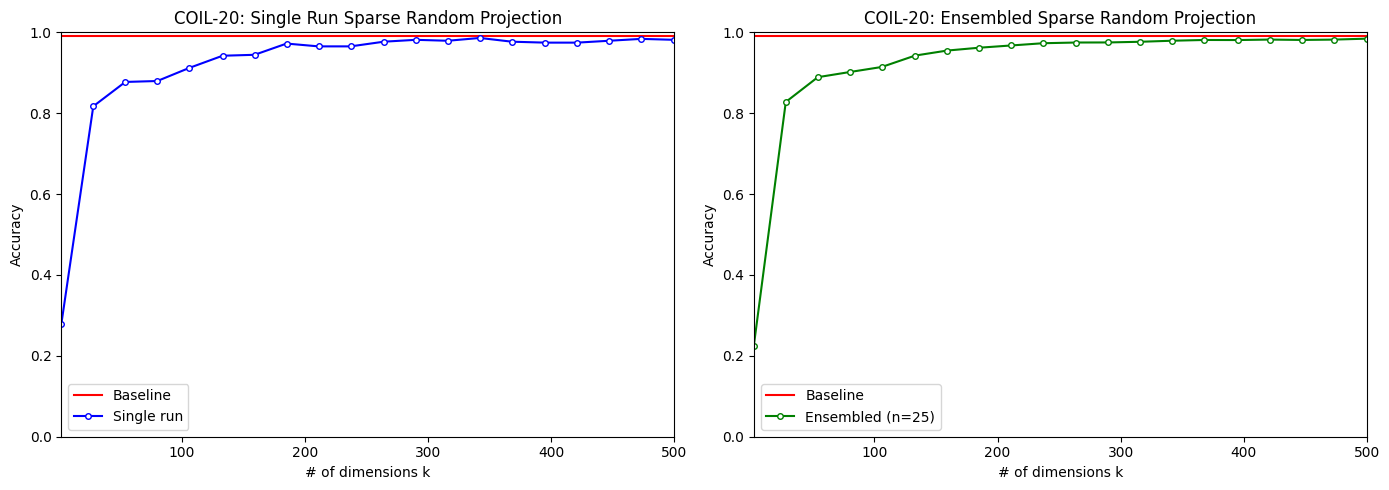

In [ ]:
# Plotting single run sparse random projection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(dims_coil, [baseline_coil] * len(dims_coil), color='r', label='Baseline')
axes[0].plot(dims_coil, accuracies_coil, color='b', label='Single run',marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[0].set_xlabel('# of dimensions k')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('COIL-20: Single Run Sparse Random Projection')
axes[0].set_xlim([2, 500])
axes[0].set_ylim([0, 1])
axes[0].legend()
# Plotting ensembled sparse random projection
axes[1].plot(dims_coil, [baseline_coil] * len(dims_coil), color='r', label='Baseline')
axes[1].plot(dims_coil, avg_accuracies_coil, color='g', label='Ensembled (n=25)',marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[1].set_xlabel('# of dimensions k')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('COIL-20: Ensembled Sparse Random Projection')
axes[1].set_xlim([2, 500])
axes[1].set_ylim([0, 1])
axes[1].legend()
plt.tight_layout()
plt.show()

**Conclusion for Dataset 1**
- The baseline accuracy without any projection is `0.9907` (99.07%), computed using a LinearSVC on the full 16,384-dimensional space.
- The *single run curve* shows **slight dips and bumps (around k = 150) due to the randomness of individual projections**.
- The *ensembled curve* (25 realizations averaged) is **visibly smoother, confirming that averaging over multiple random projections removes variance caused by any single projection matrix.**
- Also, near baseline accuracy (~99%) is recovered at roughly k=300-400 dimensions far below the JL bound of 6233, suggesting the bound is highly conservative for this dataset.

#### B. Breast Cancer Wisconsin (Diagnostic)

Description:

- It contains 569 samples of breast tumor data, each labeled as malignant or benign.
- Each sample is described by 30 numerical features, resulting in a 30-dimensional feature space.
- Features are derived from digitized images of cell nuclei, including measurements such as radius, texture, smoothness, and concavity.
- Data lives in a Euclidean feature space, where distance-based similarity measures are meaningful and suitable for evaluating random projections.


**1. Loading the dataset**

In [49]:
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.random_projection import johnson_lindenstrauss_min_dim

In [50]:
# Load the Breast Cancer dataset
X_bc, y_bc = load_breast_cancer(return_X_y=True, as_frame=False)

print('Breast Cancer shape:', X_bc.shape)
print('Number of classes:', len(np.unique(y_bc)))


Breast Cancer shape: (569, 30)
Number of classes: 2


In [51]:
# Train-test split
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42, stratify=y_bc
)

print('Train size:', X_bc_train.shape)
print('Test size: ', X_bc_test.shape)
print('Feature dimension (original):', X_bc_train.shape[1])

Train size: (398, 30)
Test size:  (171, 30)
Feature dimension (original): 30


**2. Johnson and Lindenstrauss Bound**

In [52]:
# Johnson-Lindenstrauss bound for Breast Cancer (eps=0.1)
print('Professors Johnson and Lindenstrauss say: k >=',
      johnson_lindenstrauss_min_dim(len(X_bc), eps=0.1))

Professors Johnson and Lindenstrauss say: k >= 5437


**3. Getting baseline accuracy** 

In [53]:
model_bc = LinearSVC(random_state=42, max_iter=5000)
model_bc.fit(X_bc_train, y_bc_train)
baseline_bc = metrics.accuracy_score(y_bc_test, model_bc.predict(X_bc_test))
print('Baseline accuracy (no projection): %.4f' % baseline_bc)

Baseline accuracy (no projection): 0.9474


**4. Sparse Random Projection**

In [54]:
accuracies = []

accuracies_bc = []
dims_bc = np.int32(np.linspace(2, 30, 15))

for dim in dims_bc:
    sp = SparseRandomProjection(n_components=dim, random_state=42)
    X_proj = sp.fit_transform(X_bc_train)

    model = LinearSVC(max_iter=5000)
    model.fit(X_proj, y_bc_train)

    test_proj = sp.transform(X_bc_test)
    accuracies_bc.append(metrics.accuracy_score(y_bc_test, model.predict(test_proj)))

**5. Ensembled Random Projection**

In [55]:
n_realizations = 25
accuracies_bc_ens = np.zeros((n_realizations, len(dims_bc)))

for j, dim in enumerate(dims_bc):
    for i in range(n_realizations):
        sp = SparseRandomProjection(n_components=dim, random_state=42 + i)
        X_proj = sp.fit_transform(X_bc_train)

        model = LinearSVC(max_iter=5000)
        model.fit(X_proj, y_bc_train)

        test_proj = sp.transform(X_bc_test)
        accuracies_bc_ens[i, j] = metrics.accuracy_score(
            y_bc_test, model.predict(test_proj)
        )

avg_accuracies_bc = accuracies_bc_ens.mean(axis=0)

**6. Plotting Sparse Random Projection and Ensembled random projection**

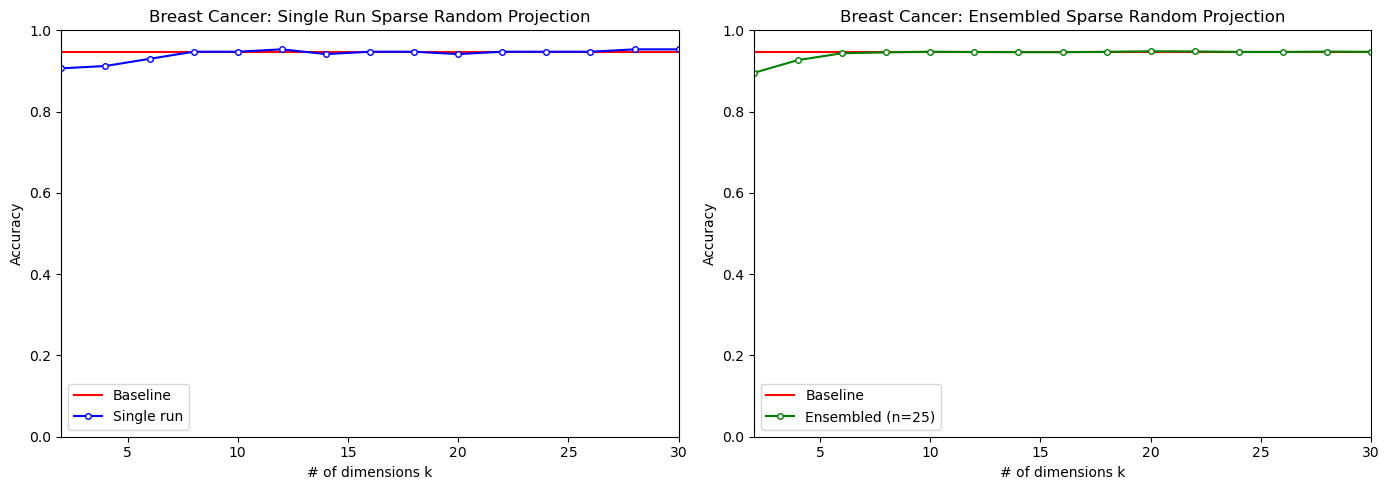

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plotting single run sparse random projection
axes[0].plot(dims_bc, [baseline_bc] * len(dims_bc), color='r', label='Baseline')
axes[0].plot(dims_bc, accuracies_bc, color='b', label='Single run',
             marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[0].set_xlabel('# of dimensions k')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Breast Cancer: Single Run Sparse Random Projection')
axes[0].set_xlim([2, 30])
axes[0].set_ylim([0, 1])
axes[0].legend()

# Plotting ensembled sparse random projection
axes[1].plot(dims_bc, [baseline_bc] * len(dims_bc), color='r', label='Baseline')
axes[1].plot(dims_bc, avg_accuracies_bc, color='g', label='Ensembled (n=25)',
             marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[1].set_xlabel('# of dimensions k')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Breast Cancer: Ensembled Sparse Random Projection')
axes[1].set_xlim([2, 30])
axes[1].set_ylim([0, 1])
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusion for Dataset 2**
- The baseline accuracy without any projection is `0.9474` (94.74%), computed using a LinearSVC on the original 30-dimensional feature space.
- The *single run curve* shows **ssmall fluctuations across different values of k.**. These variations are expected, as each random projection uses a different random matrix, which can slightly distort distances and affect classification performance.
- The *ensembled curve* (25 realizations averaged) is **visibly smoother**, again confirming that averaging over multiple random projections removes variance caused by any single projection matrix.
- Also, high accuracy is preserved even at relatively low dimensions (e.g., k≈10–15), indicating that the dataset has a **low intrinsic dimensionality** and does not require all 30 original features to achieve strong performance.

#### Comparing 'Dataset 1' and 'Dataset 2'

In [ ]:
# Graph comparison

#### Conclusion:

-
-
